In [1]:


from glms_plotting_utils import *


In [207]:
#TODO actually only the networks that had all folds finished
models_path = r"M:\analysis\Myriam_Hamon\results\AB131\whisker_0\server/models/short_window/"

all_results = []

path = r"M:\analysis\Myriam_Hamon\combined_results\AB131\whisker_0\unit_glm\poisson_10Hz_with_offset\AB131\whisker_0\unit_glm\models\f058f2a_model_full_fold0_results.parquet"
# Load DataFrame

df = pd.read_parquet(path)


all_results.append(df)


df = pd.concat(all_results, ignore_index=True)


In [70]:
df.keys()

Index(['neuron_id', 'lambda_opt', 'train_ll', 'train_score', 'train_corr',
       'train_mi', 'test_ll', 'test_score', 'coef', 'y_train', 'y_test',
       'y_pred', 'y_train_pred', 'test_corr', 'test_mi', 'n_bins', 'fold',
       'train_trials', 'test_trials', 'model_name', 'predictors'],
      dtype='object')

In [71]:
df['y_train'].to_numpy()[0]

'[0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 2, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,

In [208]:
y_train_pred = np.array(ast.literal_eval(df['y_train_pred'].to_numpy()[0]))
np.mean(y_train_pred)

0.9885777459817642

In [209]:
y_train_pred

array([1.0052455 , 0.99814654, 0.99810598, ..., 0.98438316, 0.9952329 ,
       0.99443931])

In [196]:
y_train_pred

array([0.99241176, 0.99617147, 0.99553783, ..., 0.99883769, 0.9954203 ,
       0.99740451])

In [197]:
y_train_pred = np.array(ast.literal_eval(df['y_pred'].to_numpy()[0]))
np.mean(y_train_pred)


0.9992672051099437

In [198]:
y_train = np.array(ast.literal_eval(df['y_train'].to_numpy()[0]))

In [199]:
np.mean(y_train)

1.0001572327044026

In [174]:
df['test_corr']

0   NaN
Name: test_corr, dtype: float64

In [8]:
experimenter = 'Axel_Bisi'
nwb_path = os.path.join('\\\\sv-nas1.rcp.epfl.ch', 'Petersen-Lab', 'analysis', experimenter, 'NWBFull')
output_folder_base = r"M:\analysis\Myriam_Hamon\results\AB131\whisker_0\short_window_plots"

# subject_id = 'AB130'
# all_nwb_names = os.listdir(nwb_path)
# nwb_names = [name for name in all_nwb_names if subject_id in name]
# subject_nwb_files = [os.path.join(nwb_path, name) for name in nwb_names]
# subject_nwb_neural_files = []
# Keep whisker day 0 files with neural data
nwb_file = r"M:\analysis\Myriam_Hamon\AB131_20240905_123601.nwb"

beh, day = nwb_reader.get_bhv_type_and_training_day_index(nwb_file)
if beh=='whisker' and day==0:
    unit_table = nwb_reader.get_unit_table(nwb_file)
    # unit_table = unit_table.sample(frac=1)
    unit_table = unit_table[unit_table['bc_label']=='good']
    # unit_table = unit_table[unit_table['ccf_parent_acronym'].isin(['SSp-bfd', 'SSs'])]
    unit_table = unit_table[unit_table['firing_rate'].astype(float).ge(2.0)]
    unit_table = unit_table[~unit_table['ccf_acronym'].isin(allen_utils.get_excluded_areas())]
    # Keep original NWB index as a column
    unit_table['original_unit_id'] = unit_table.index

    # Now assign your own running neuron_id for glm indexing
    unit_table = unit_table.reset_index(drop=True)
    unit_table['neuron_id'] = unit_table.index
    # Use index as new column named "unit_id", then reset
    neurons_ccf = unit_table['ccf_parent_acronym'].values


trials_df = nwb_reader.get_trial_table(nwb_file)
trials_df = trials_df[(trials_df['context'] == 'active') &(trials_df['perf'] != 6)].copy()
trials_df = trials_df.reset_index(drop=True)


C:\Users\mhamon\AppData\Local\anaconda3\envs\nwb_analysis_env\Lib\site-packages\hdmf\spec\namespace.py:535: UserWarning: Ignoring cached namespace 'hdmf-common' version 1.5.1 because version 1.8.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."
C:\Users\mhamon\AppData\Local\anaconda3\envs\nwb_analysis_env\Lib\site-packages\hdmf\spec\namespace.py:535: UserWarning: Ignoring cached namespace 'core' version 2.6.0-alpha because version 2.7.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."
C:\Users\mhamon\AppData\Local\anaconda3\envs\nwb_analysis_env\Lib\site-packages\hdmf\spec\namespace.py:535: UserWarning: Ignoring cached namespace 'hdmf-experimental' version 0.2.0 because version 0.5.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."
C:\Users\mhamon\AppData\Local\anaconda3\envs\nwb_analysis_env\Lib\site-packages\

In [9]:
import ast
import plotting_utils as putils
def plot_trial_grid_predictions(results_df, trial_table, neuron_id, bin_size):
    """
    Plot predictions for a single neuron across trials in a grid format.
    :param results_df: DataFrame with model results
    :param trial_table: DataFrame with trial information
    :param neuron_id: int, ID of the neuron to plot
    :param bin_size: float, size of time bin in seconds
    """

    # Plotting params
    n_rows, n_cols = 5, 5
    trials_to_plot = min(n_rows*n_cols, len(trial_table))

    # Get neuron results
    results_df_sub = results_df[results_df['neuron_id'] == neuron_id]
    y_test = results_df_sub['y_test'].values[0]
    y_pred = results_df_sub['y_pred'].values[0]
    n_bins = results_df_sub['n_bins'].values[0]
    y_test = np.array(ast.literal_eval(y_test))
    y_pred = np.array(ast.literal_eval(y_pred))

    # Format data into (n_trials, n_bins)
    n_trials = y_pred.shape[0] // n_bins
    y_test = y_test.reshape(n_trials, n_bins)
    y_pred = y_pred.reshape(n_trials, n_bins)

    # Order test trial temporally
    test_trial_ids =  np.array(ast.literal_eval(results_df_sub['test_trials'].values[0]))
    test_trial_id_order =  np.argsort(test_trial_ids)
    y_test = y_test[test_trial_id_order,:]
    y_pred = y_pred[test_trial_id_order,:]

    trials_test_df = trial_table[trial_table['trial_id'].isin(test_trial_ids)]
    trials_test_df = trials_test_df.sort_values(by='trial_id', ascending=True)
    trials_test_df = trials_test_df.reset_index(drop=True)
    trials_test_df = trials_test_df.iloc[:trials_to_plot]

    # Create figure
    fig, axs = plt.subplots(n_rows, n_cols, figsize=(18, 12), sharex=False, sharey=False)
    axs = axs.flatten()


    window_bounds_sec = (-1, 2)
    time_stim = 0
    time = np.linspace(window_bounds_sec[0] + bin_size/2,
                   window_bounds_sec[1] - bin_size/2,
                   n_bins)

    for idx, row in trials_test_df.iterrows():
        ax = axs[idx]
        ax.set_title('Trial {}'.format(row['trial_id']), fontsize=10)
        putils.remove_top_right_frame(ax)
        ax.set_ylim(0, 10)
        ax.set_ylabel('Spikes', fontsize=10)
        ax.set_yticks([0, 10])
        ax.set_yticklabels([0, 10], fontsize=10)
        ax.set_xlabel('Time (s)', fontsize=10)


        trial_type = row['trial_type']
        if trial_type == 'whisker_trial':
            ax.axvline(time_stim, color='forestgreen', linestyle='-', linewidth=1)
        elif trial_type == 'auditory_trial':
            ax.axvline(time_stim, color='mediumblue', linestyle='-', linewidth=1)
        elif trial_type == 'no_stim_trial':
            ax.axvline(time_stim, color='k', linestyle='-', linewidth=1)

        # Plot target and predictions
        ax.plot(time, y_pred[idx], color='red', linewidth=1.5)
        ax.step(time, y_test[idx], where='mid', color='black', alpha=0.9, linewidth=1.5)

    title = (f'GLM predictions on test trials - unit {neuron_id}, '
             f'$R$= {results_df_sub["test_corr"].values[0]:.2f}')
    fig.suptitle(title, fontsize=16)
    fig.tight_layout()
    fig.align_ylabels()

    plt.show()

    return


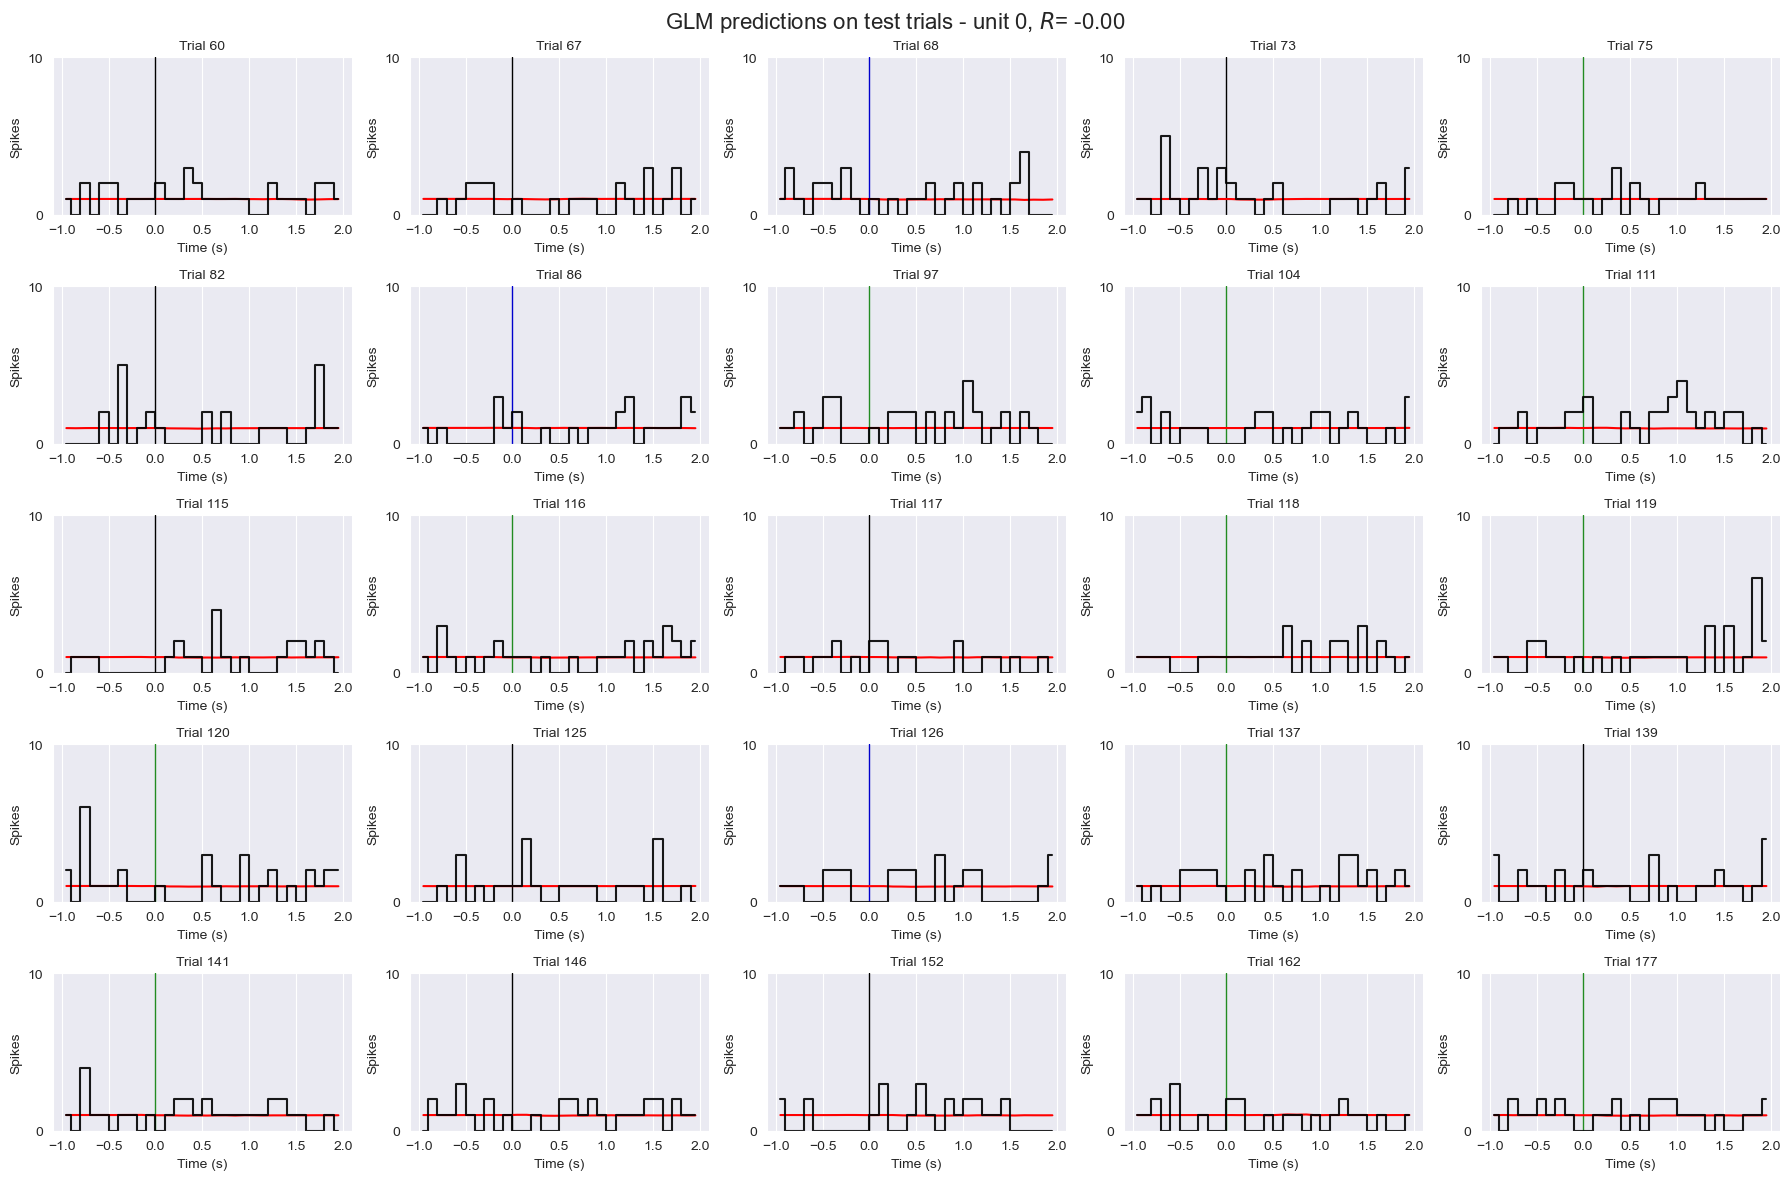

In [217]:
 plot_trial_grid_predictions(df, trials_df, df['neuron_id'].iloc[0], 0.1)

In [11]:
%matplotlib inline


In [210]:
df['coef'].to_numpy()[0]

'[-0.0036156091065247366, -0.009859954404094682, -0.002137692011357022, -0.0012524990238227175, 0.0003183014967182442, 0.004401699760243315, 0.001634910150085339, -0.005013160419265431, -0.002448910320677334, 0.0025633800669473384, -0.005672496364582115, -0.0006057799776017938, -0.004330095855641548, -0.0005845097832580906, 0.0006678076102050529, -0.00042191610611614993, 0.0021768167683897783, -0.0009286179080996196, -0.001555920705815623, 0.00027209496006212584, 0.0041061206164794955, 0.004741779002783879, -0.0013176144958535244, -0.0013649500796889917, 0.0027258533351796313, -0.0020272259042904577, 0.0020631020800937804, -0.0005919691033495595, 0.0027382519225002534, 0.0008673195179689968, -0.0020669918506944635, 0.004502062892977534, 0.0016101405603674674, 0.0013653187351171, 0.0003298183927354853, -0.0034292343546688574, 0.003581906054191147, 0.00016360632309300543, -0.0078051998658067254, 0.0009177419573141945, 0.005817066235579065, -0.007019340145893755]'

In [211]:
df['predictors'].to_numpy()

array(['["trial_index_scaled", "offset", "dlc_lick_onset_t-0.30s", "dlc_lick_onset_t-0.20s", "dlc_lick_onset_t-0.10s", "dlc_lick_onset_t+0.00s", "dlc_lick_onset_t+0.10s", "dlc_lick_onset_t+0.20s", "dlc_lick_onset_t+0.30s", "dlc_lick_onset_t+0.40s", "dlc_lick_onset_t+0.50s", "auditory_stim_t-0.30s", "auditory_stim_t-0.20s", "auditory_stim_t-0.10s", "auditory_stim_t+0.00s", "auditory_stim_t+0.10s", "auditory_stim_t+0.20s", "auditory_stim_t+0.30s", "auditory_stim_t+0.40s", "auditory_stim_t+0.50s", "whisker_stim_t-0.30s", "whisker_stim_t-0.20s", "whisker_stim_t-0.10s", "whisker_stim_t+0.00s", "whisker_stim_t+0.10s", "whisker_stim_t+0.20s", "whisker_stim_t+0.30s", "whisker_stim_t+0.40s", "whisker_stim_t+0.50s", "piezo_reward_t-0.30s", "piezo_reward_t-0.20s", "piezo_reward_t-0.10s", "piezo_reward_t+0.00s", "piezo_reward_t+0.10s", "piezo_reward_t+0.20s", "piezo_reward_t+0.30s", "piezo_reward_t+0.40s", "piezo_reward_t+0.50s", "jaw_dist", "pupil_area", "whisker_vel", "nose_dist"]'],
      dtype

In [212]:
coef = np.array(ast.literal_eval(df['coef'].to_numpy()[0]))


In [213]:
np.mean(coef)

-0.0003924902225731182

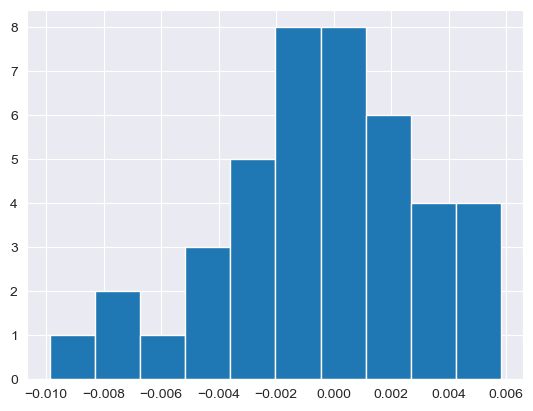

In [214]:
plt.hist(coef)
plt.show()

In [215]:
np.argmax(coef)

40

In [182]:
coef[0]

5e-324

In [216]:
np.argmin(coef)

1

In [49]:
coef[18]

0.16797742620344477

In [146]:
np.array(ast.literal_eval(df['predictors'].to_numpy()[0]))[41]

'nose_dist'

WITH OFFSEt

In [118]:
models_path = r"M:\analysis\Myriam_Hamon\results\AB131\whisker_0\server/models/short_window/"

all_results = []

path = r"M:\analysis\Myriam_Hamon\combined_results\AB131\whisker_0\unit_glm\one_hz_with_offset\AB131\whisker_0\unit_glm\models\08d1bd5_model_full_fold0_results.parquet"
# Load DataFrame

df = pd.read_parquet(path)


all_results.append(df)


df = pd.concat(all_results, ignore_index=True)


In [119]:
y_train_pred = np.array(ast.literal_eval(df['y_train_pred'].to_numpy()[0]))
np.mean(y_train_pred) / 0.1

1.0567638398371215

In [120]:
y_train_pred = np.array(ast.literal_eval(df['y_pred'].to_numpy()[0]))
np.mean(y_train_pred)/0.1


1.0501291255031708

In [121]:
y_train_pred

array([0.11686948, 0.11780067, 0.1192892 , ..., 0.08931646, 0.08950691,
       0.0896602 ])

In [122]:
y_train = np.array(ast.literal_eval(df['y_train'].to_numpy()[0]))
np.mean(y_train)/0.1


1.0094339622641508

In [123]:
df['test_corr']

0    0.002548
Name: test_corr, dtype: float64

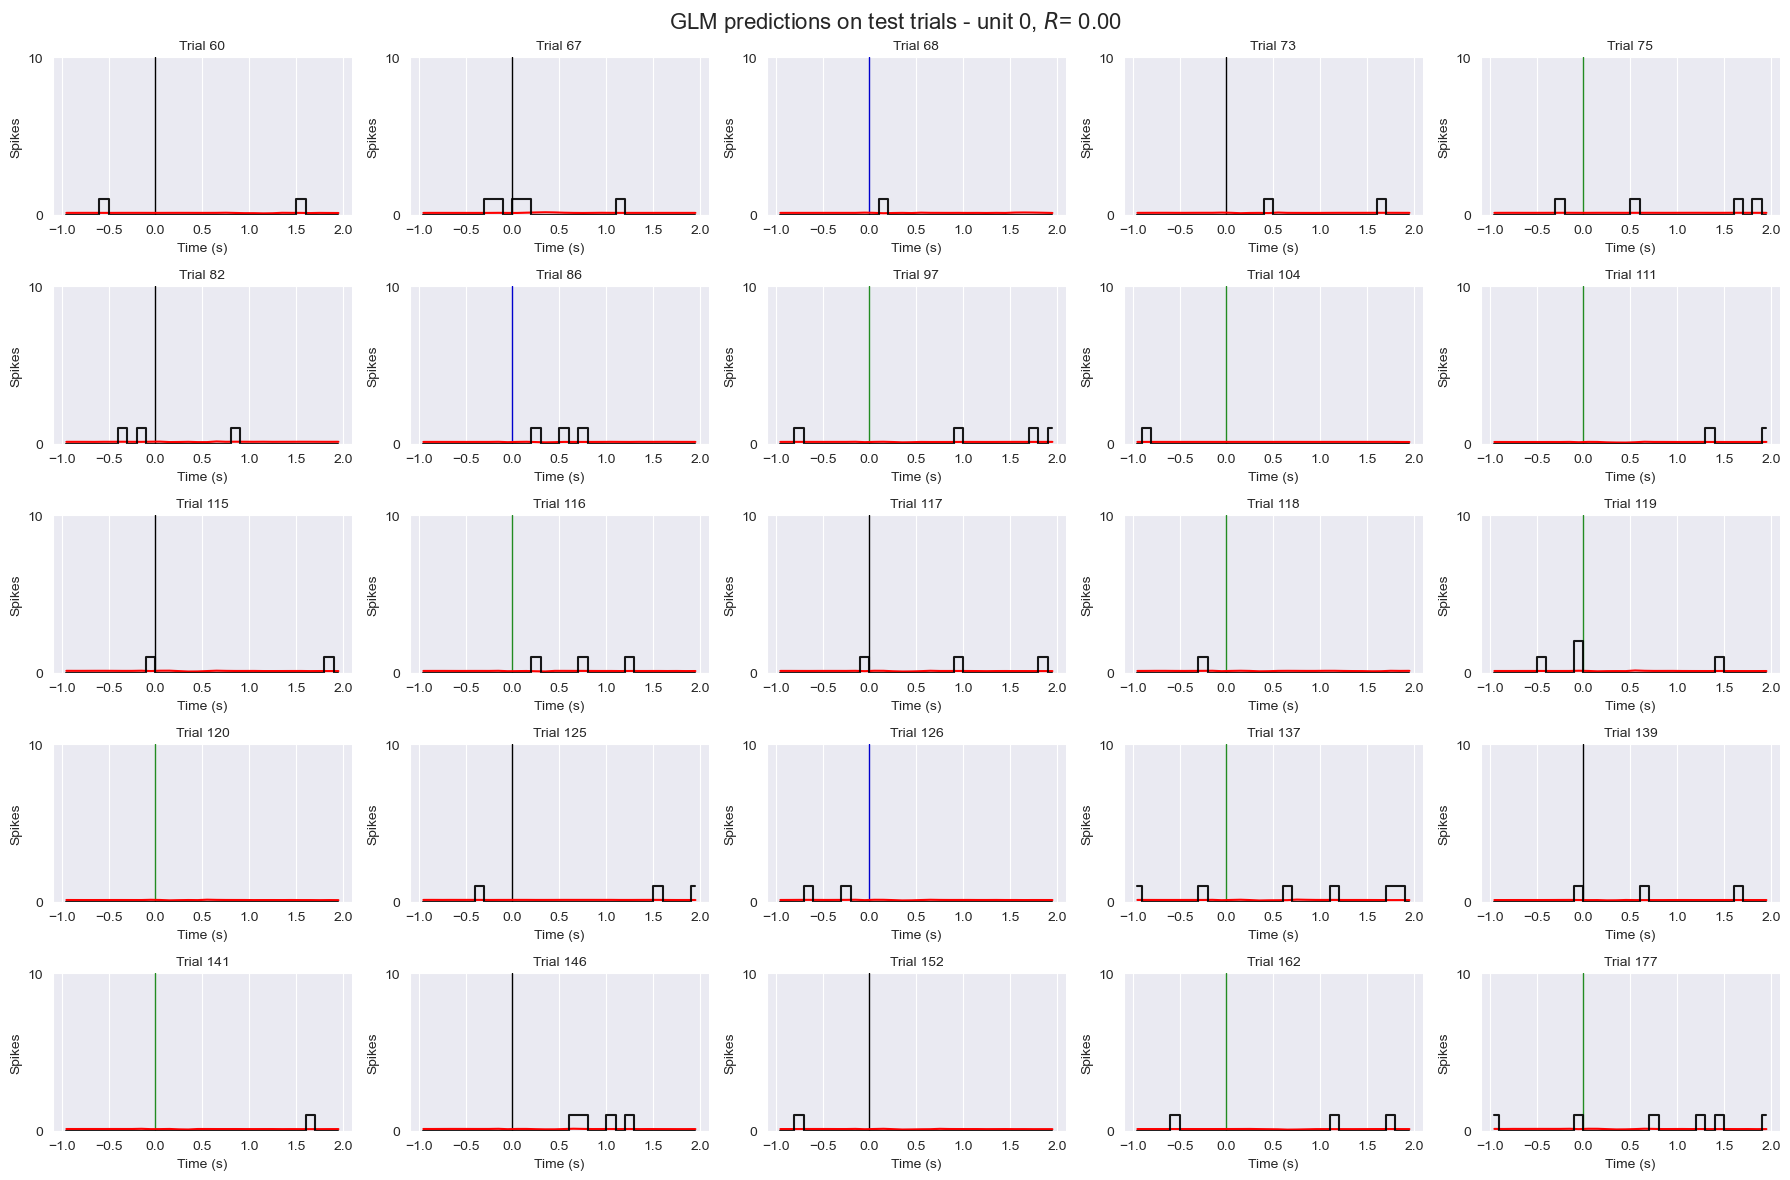

In [124]:
 plot_trial_grid_predictions(df, trials_df, df['neuron_id'].iloc[0], 0.1)


In [102]:
coef = np.array(ast.literal_eval(df['coef'].to_numpy()[0]))


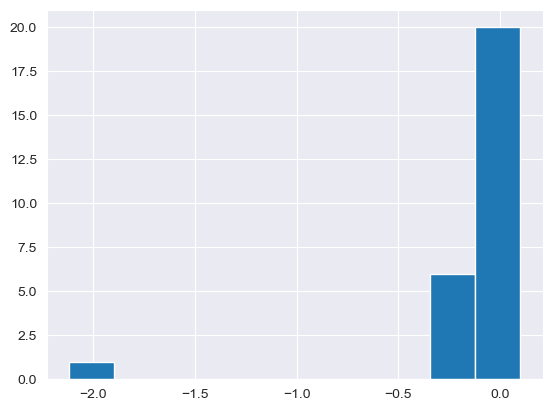

In [103]:
plt.hist(coef)
plt.show()

In [104]:
np.argmin(coef)

1

In [105]:
df['predictors'].to_numpy()

array(['["trial_index_scaled", "offset", "dlc_lick_onset_t-0.20s", "dlc_lick_onset_t-0.10s", "dlc_lick_onset_t+0.00s", "dlc_lick_onset_t+0.10s", "dlc_lick_onset_t+0.20s", "dlc_lick_onset_t+0.30s", "dlc_lick_onset_t+0.40s", "auditory_stim_t-0.20s", "auditory_stim_t-0.10s", "auditory_stim_t+0.00s", "auditory_stim_t+0.10s", "auditory_stim_t+0.20s", "auditory_stim_t+0.30s", "auditory_stim_t+0.40s", "whisker_stim_t-0.20s", "whisker_stim_t-0.10s", "whisker_stim_t+0.00s", "whisker_stim_t+0.10s", "whisker_stim_t+0.20s", "whisker_stim_t+0.30s", "whisker_stim_t+0.40s", "jaw_dist", "pupil_area", "whisker_vel", "nose_dist"]'],
      dtype=object)

In [133]:
coef_no = np.concatenate(([coef[0]],coef[2:]))

In [134]:
len(coef_no)

26

In [135]:
np.mean(coef_no)

-0.04194527109296212

In [148]:
#TODO actually only the networks that had all folds finished
models_path = r"M:\analysis\Myriam_Hamon\results\AB131\whisker_0\server/models/short_window/"

all_results = []

path = r"M:\analysis\Myriam_Hamon\combined_results\AB131\whisker_0\unit_glm\tests_models/neuron_test_with_offset\AB131\whisker_0\unit_glm\models\08d1bd5_model_full_fold0_results.parquet"
# Load DataFrame

df = pd.read_parquet(path)


all_results.append(df)


df = pd.concat(all_results, ignore_index=True)

In [149]:

def plot_model_comparison(
    neuron_ids, df_full, trials_df, output_folder, name,
    bin_size=0.1, zscore=False
):
    """
    Plot average neural data, full model, and reduced model predictions
    across multiple neurons and trial types, with SEM across folds.
    """

    # ------------------------
    # FULL MODEL
    # ------------------------

    all_y_test, all_y_pred_full = {}, {}

    for nid in neuron_ids:
        res_all = df_full[df_full["neuron_id"] == nid]
        if res_all.empty:
            print("No data for neuron", nid)
            continue

        for res in res_all.itertuples(index=False):
            y_test = res.y_test_array
            y_pred = res.y_pred_array
            n_bins = res.n_bins

            n_trials = y_pred.shape[0] // n_bins
            y_test = y_test.reshape(n_trials, n_bins)
            y_pred = y_pred.reshape(n_trials, n_bins)

            test_trial_ids = np.array(ast.literal_eval(res.test_trials))
            order = np.argsort(test_trial_ids)
            y_test = y_test[order, :]
            y_pred = y_pred[order, :]
            trials_test_df = trials_df.iloc[test_trial_ids[order], :]

            for trial_type in trials_test_df["behav_type"].unique():
                idx = np.where(trials_test_df["behav_type"] == trial_type)[0]
                if len(idx) == 0:
                    continue

                test_mean = np.mean(y_test[idx], axis=0)
                pred_mean = np.mean(y_pred[idx], axis=0)

                if zscore:
                    test_mean = zscore_f(test_mean)
                    pred_mean = zscore_f(pred_mean)

                all_y_test.setdefault(trial_type, []).append(test_mean)
                all_y_pred_full.setdefault(trial_type, []).append(pred_mean)

    # ------------------------
    # REDUCED MODEL
    # ------------------------

    # ------------------------
    # Fits (average correlation)
    # ------------------------
    fits_full = (
        df_full[df_full["neuron_id"].isin(neuron_ids)]["test_corr"]
        .astype(float).mean()
    )

    # ------------------------
    # PLOTTING
    # ------------------------
    trial_types = sorted(all_y_test.keys())
    plt.ioff()
    fig, axes = plt.subplots(1, len(trial_types), figsize=(15, 5), sharey=True)
    window_bounds_sec = (-1, 2)
    time_stim = 0
    time = np.linspace(window_bounds_sec[0] + bin_size/2,
                       window_bounds_sec[1] - bin_size/2,
                       n_bins)



    if len(trial_types) == 1:
        axes = [axes]

    for ax, trial_type in zip(axes, trial_types):
        putils.remove_top_right_frame(ax)
        ax.set_ylabel("Spikes", fontsize=10)
        ax.set_xlabel("Time (s)", fontsize=10)


        # Stim marker
        if trial_type == "whisker_hit":
            ax.axvline(time_stim, color="forestgreen", linestyle="-", linewidth=1)
        elif trial_type == "whisker_miss":
            ax.axvline(time_stim, color="orange", linestyle="-", linewidth=1)
        elif trial_type == "auditory_hit":
            ax.axvline(time_stim, color="mediumblue", linestyle="-", linewidth=1)
        elif trial_type == "auditory_miss":
            ax.axvline(time_stim, color="skyblue", linestyle="-", linewidth=1)
        elif trial_type == "catch":
            ax.axvline(time_stim, color="gray", linestyle="-", linewidth=1)
        elif trial_type == "correct_rejection":
            ax.axvline(time_stim, color="black", linestyle="-", linewidth=1)

        # --- Data
        data_stack = np.stack(all_y_test[trial_type])
        mean_data = data_stack.mean(axis=0)[:80]
        sem_data = data_stack.std(axis=0, ddof=1) / np.sqrt(data_stack.shape[0])
        ax.plot(time, mean_data, color="black", label="data")
        ax.fill_between(time, mean_data - sem_data[:80], mean_data + sem_data[:80], color="black", alpha=0.3)

        # --- Full model
        full_stack = np.stack(all_y_pred_full[trial_type])
        mean_full = full_stack.mean(axis=0)[:80]
        sem_full = full_stack.std(axis=0, ddof=1) / np.sqrt(full_stack.shape[0])
        ax.plot(time, mean_full, color="green", label="full")
        ax.fill_between(time, mean_full - sem_full[:80], mean_full + sem_full[:80], color="green", alpha=0.3)



        ax.set_title(trial_type, fontsize=14)
    if len(neuron_ids) == 1:
        fig.suptitle(
            f"full fit={fits_full:.3f}"
        )
    axes[min(2, len(axes)-1)].legend(fontsize=8)
    plt.tight_layout()
    # plt.savefig(output_folder + f'/{name}.png')
    plt.show()
    return


In [150]:
df['y_test_array'] = df['y_test'].apply(lambda x: np.array(ast.literal_eval(x)))
df['y_pred_array'] = df['y_pred'].apply(lambda x: np.array(ast.literal_eval(x)))
trials_df["behav_type"] = trials_df.apply(classify_trial, axis=1)


C:\Users\mhamon\AppData\Local\anaconda3\envs\nwb_analysis_env\Lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\mhamon\AppData\Local\anaconda3\envs\nwb_analysis_env\Lib\site-packages\numpy\core\_methods.py:195: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


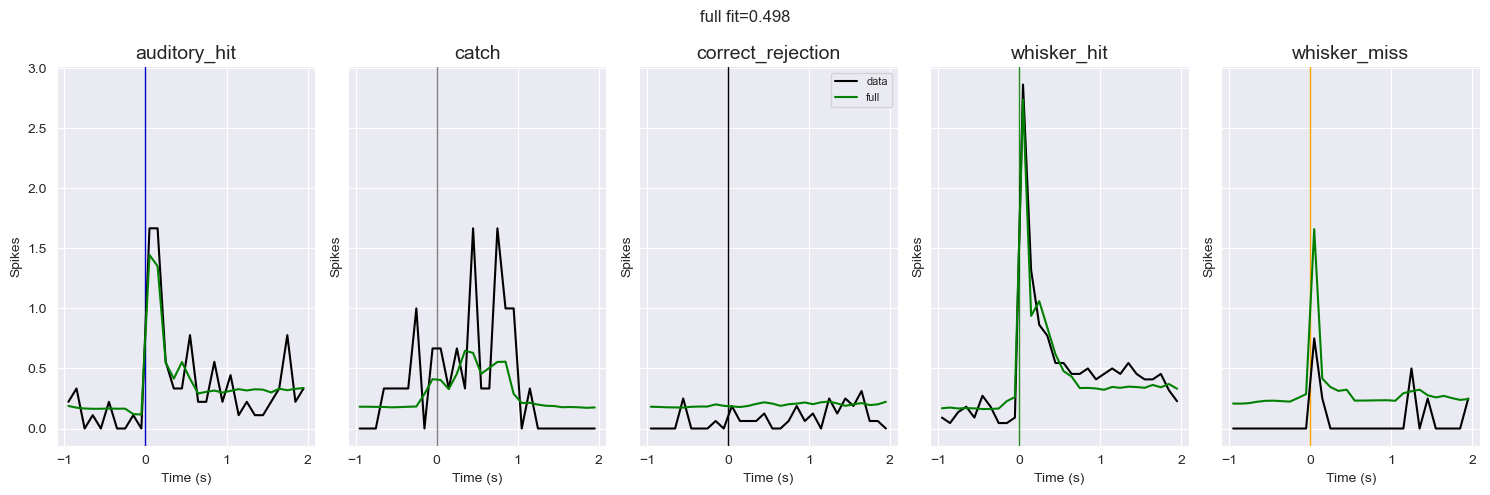

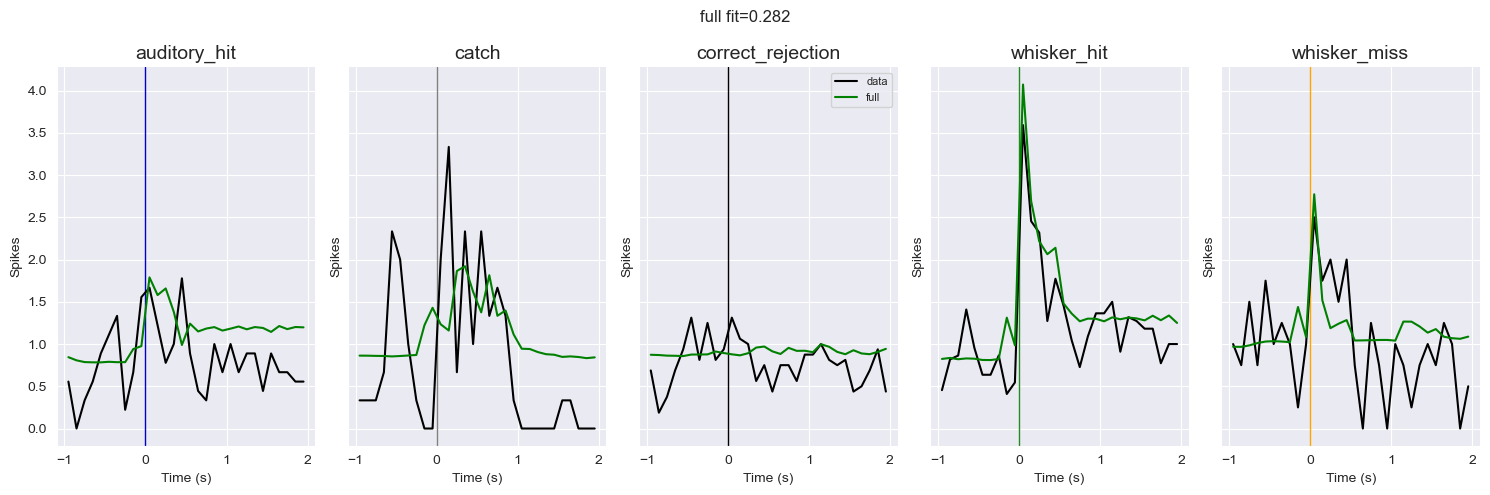

In [151]:
for neuron in df['neuron_id'].unique():
        plot_model_comparison(
        [neuron], df, trials_df, None,neuron,
         bin_size=0.1, zscore = False
    )

In [143]:
df

,neuron_id,lambda_opt,train_ll,train_score,train_corr,train_mi,test_ll,test_score,coef,y_train,...,test_corr,test_mi,n_bins,fold,train_trials,test_trials,model_name,predictors,y_test_array,y_pred_array
0,0,0.000150,-3693.678267,0.222359,0.471197,0.520548,-850.369013,0.268862,"[0.11904194867223729, -1.5656460404115236, 0.8...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",...,0.497639,0.657551,30,0,"[0, 1, 2, 3, 4, 5, 7, 8, 11, 12, 13, 14, 17, 1...","[6, 9, 10, 15, 16, 19, 24, 30, 33, 45, 46, 60,...",full,"[""trial_index_scaled"", ""offset"", ""dlc_lick_ons...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.167542605641731, 0.1665767674470678, 0.1627..."
1,1,0.002236,-5443.858751,0.117309,0.362258,0.160693,-1512.308063,0.077945,"[0.25684399317962936, -0.14239481013747432, 0....","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",...,0.282188,0.097879,30,0,"[0, 1, 2, 3, 4, 5, 7, 8, 11, 12, 13, 14, 17, 1...","[6, 9, 10, 15, 16, 19, 24, 30, 33, 45, 46, 60,...",full,"[""trial_index_scaled"", ""offset"", ""dlc_lick_ons...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.7462095400455565, 0.7444992392483077, 0.740..."


In [144]:
#TODO actually only the networks that had all folds finished
models_path = r"M:\analysis\Myriam_Hamon\results\AB131\whisker_0\server/models/short_window/"

all_results = []

path = r"M:\analysis\Myriam_Hamon\combined_results\AB131\whisker_0\unit_glm\neuron_test_with_longer_kernels\AB131\whisker_0\unit_glm\models\08d1bd5_model_full_fold0_results.parquet"
# Load DataFrame

df = pd.read_parquet(path)


all_results.append(df)


df = pd.concat(all_results, ignore_index=True)

In [ ]:
"This was nueon 29 and 34"


In [145]:
df['y_test_array'] = df['y_test'].apply(lambda x: np.array(ast.literal_eval(x)))
df['y_pred_array'] = df['y_pred'].apply(lambda x: np.array(ast.literal_eval(x)))
trials_df["behav_type"] = trials_df.apply(classify_trial, axis=1)


C:\Users\mhamon\AppData\Local\anaconda3\envs\nwb_analysis_env\Lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\mhamon\AppData\Local\anaconda3\envs\nwb_analysis_env\Lib\site-packages\numpy\core\_methods.py:195: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


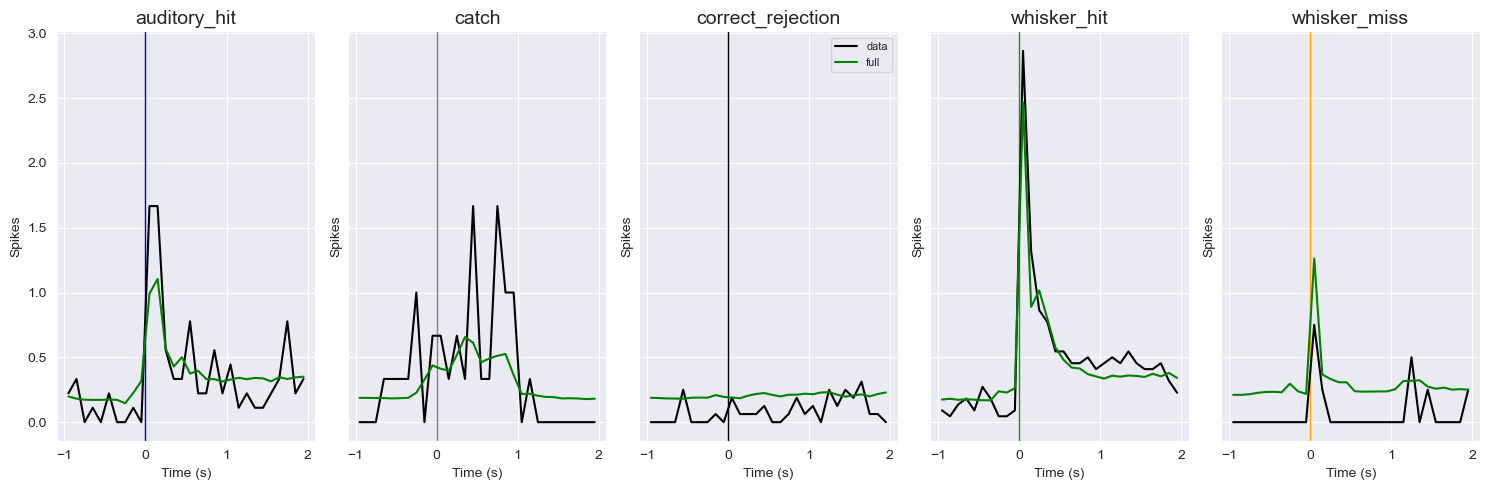

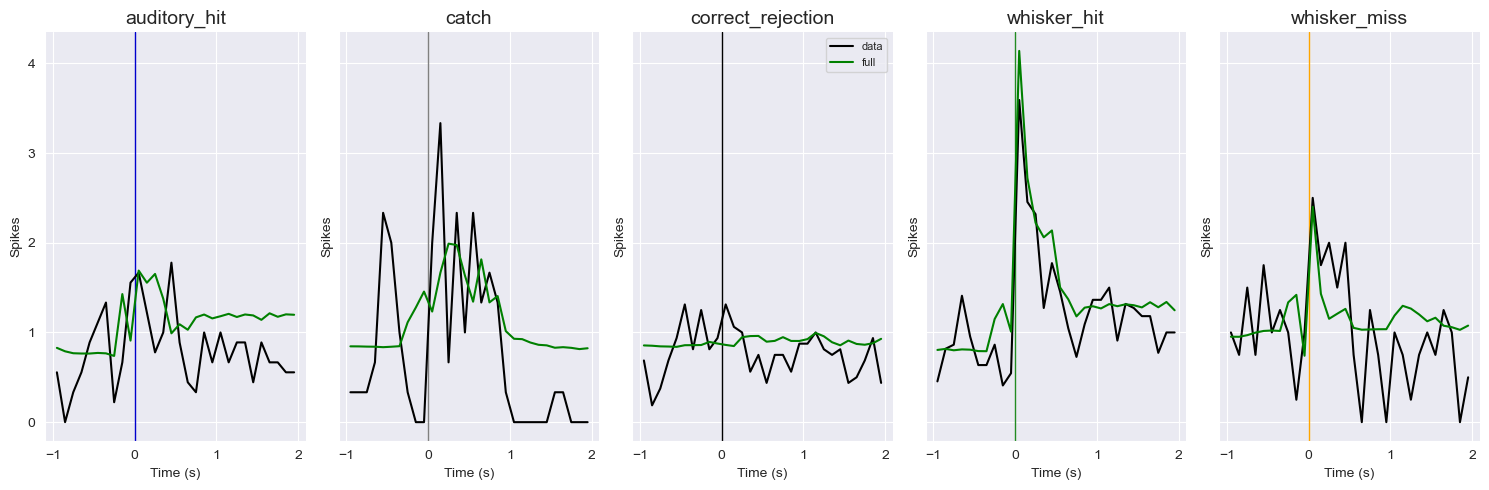

In [146]:
for neuron in df['neuron_id'].unique():
        plot_model_comparison(
        [neuron], df, trials_df, None,neuron,
         bin_size=0.1, zscore = False
    )

In [152]:
models_path = r"M:\analysis\Myriam_Hamon\results\AB131\whisker_0\server/models/short_window/"

all_results = []

path = r"M:\analysis\Myriam_Hamon\combined_results\AB131\whisker_0\unit_glm\tests_models\neuron_test_trash\AB131\whisker_0\unit_glm\models\08d1bd5_model_full_fold0_results.parquet"
# Load DataFrame

df = pd.read_parquet(path)


all_results.append(df)


df = pd.concat(all_results, ignore_index=True)


In [153]:
df['y_test_array'] = df['y_test'].apply(lambda x: np.array(ast.literal_eval(x)))
df['y_pred_array'] = df['y_pred'].apply(lambda x: np.array(ast.literal_eval(x)))
trials_df["behav_type"] = trials_df.apply(classify_trial, axis=1)


C:\Users\mhamon\AppData\Local\anaconda3\envs\nwb_analysis_env\Lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\mhamon\AppData\Local\anaconda3\envs\nwb_analysis_env\Lib\site-packages\numpy\core\_methods.py:195: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


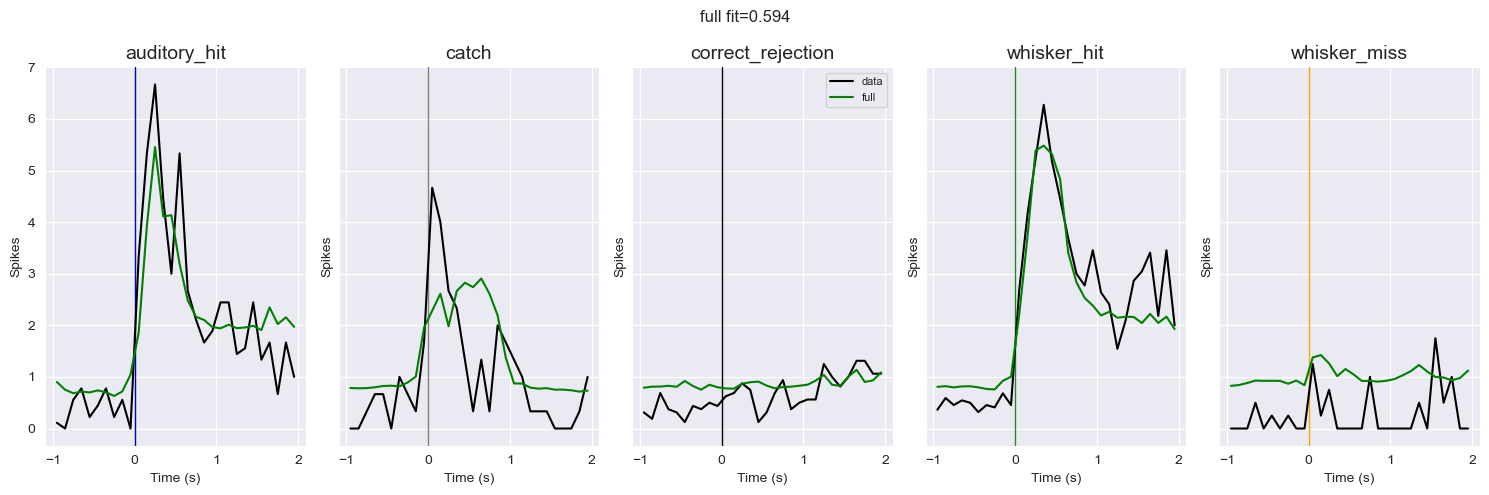

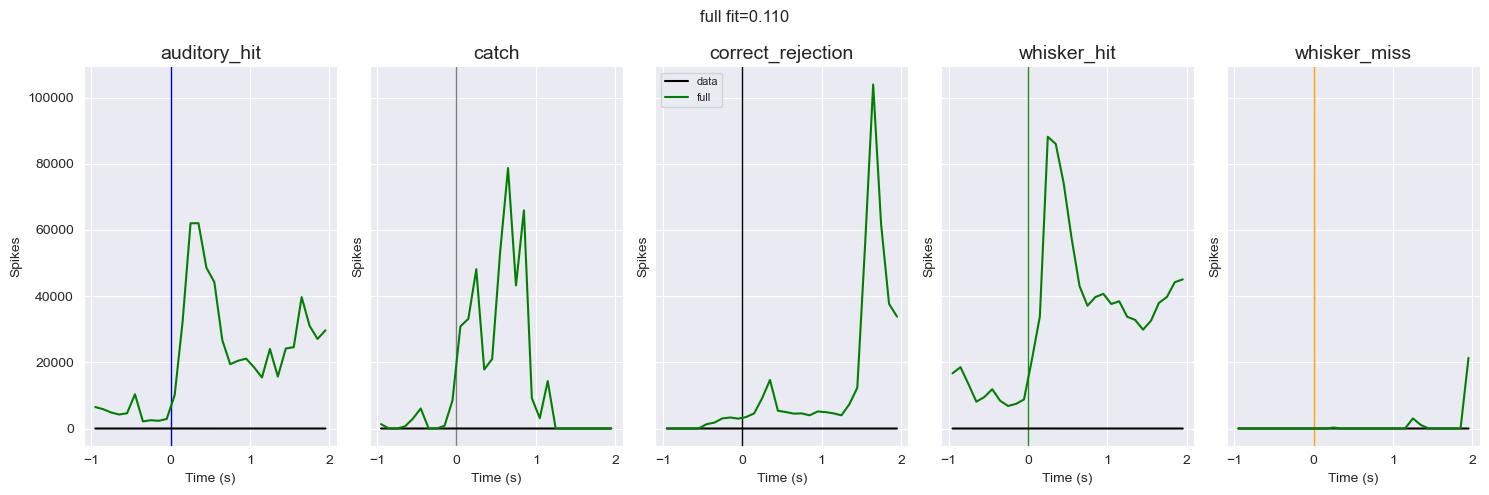

In [154]:
for neuron in df['neuron_id'].unique():
        plot_model_comparison(
        [neuron], df, trials_df, None,neuron,
         bin_size=0.1, zscore = False
    )

In [154]:
"This was nueon 50 and 75"

array([0, 1], dtype=int64)